# captum — PyTorch Attribution

Captum is PyTorch's native interpretability library, providing gradient-based attribution methods such as Integrated Gradients and a fully Torch-compatible KernelSHAP implementation. This notebook benchmarks captum's first-order attribution methods against Shapley-based approaches from `shapiq` on neural network models, assessing both explanation quality and runtime. It directly addresses Research Question 4: whether gradient-based attribution can match Shapley fidelity for deep learning models.

In [1]:
from Models.load_and_train import TrainingConfig
# First load and train the models on different datasets
all_combi_configs = TrainingConfig.get_all_configs(pytorch=True)
all_trained_models = [config.train(verbose=True) for config in all_combi_configs]

print("All models trained successfully!")
print(f"Total number of trained models: {len(all_trained_models)}")

Trained pytorch_neural_network on california_housing
Trained pytorch_neural_network on ames_housing
Trained pytorch_neural_network on covertype
All models trained successfully!
Total number of trained models: 3


In [3]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from captum.attr import ShapleyValueSampling, KernelShap, GradientShap, DeepLiftShap

/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== California Housing (regression) ===
  Shapley Value Sampling...
  Kernel SHAP...
  Gradient SHAP...
  DeepLift SHAP...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/captum/attr/_core/lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/captum/attr/_core/deep_lift.py:811: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


  Runtimes: Shapley Value Sampling: 0.027s | Kernel SHAP: 0.153s | Gradient SHAP: 0.006s | DeepLift SHAP: 0.048s


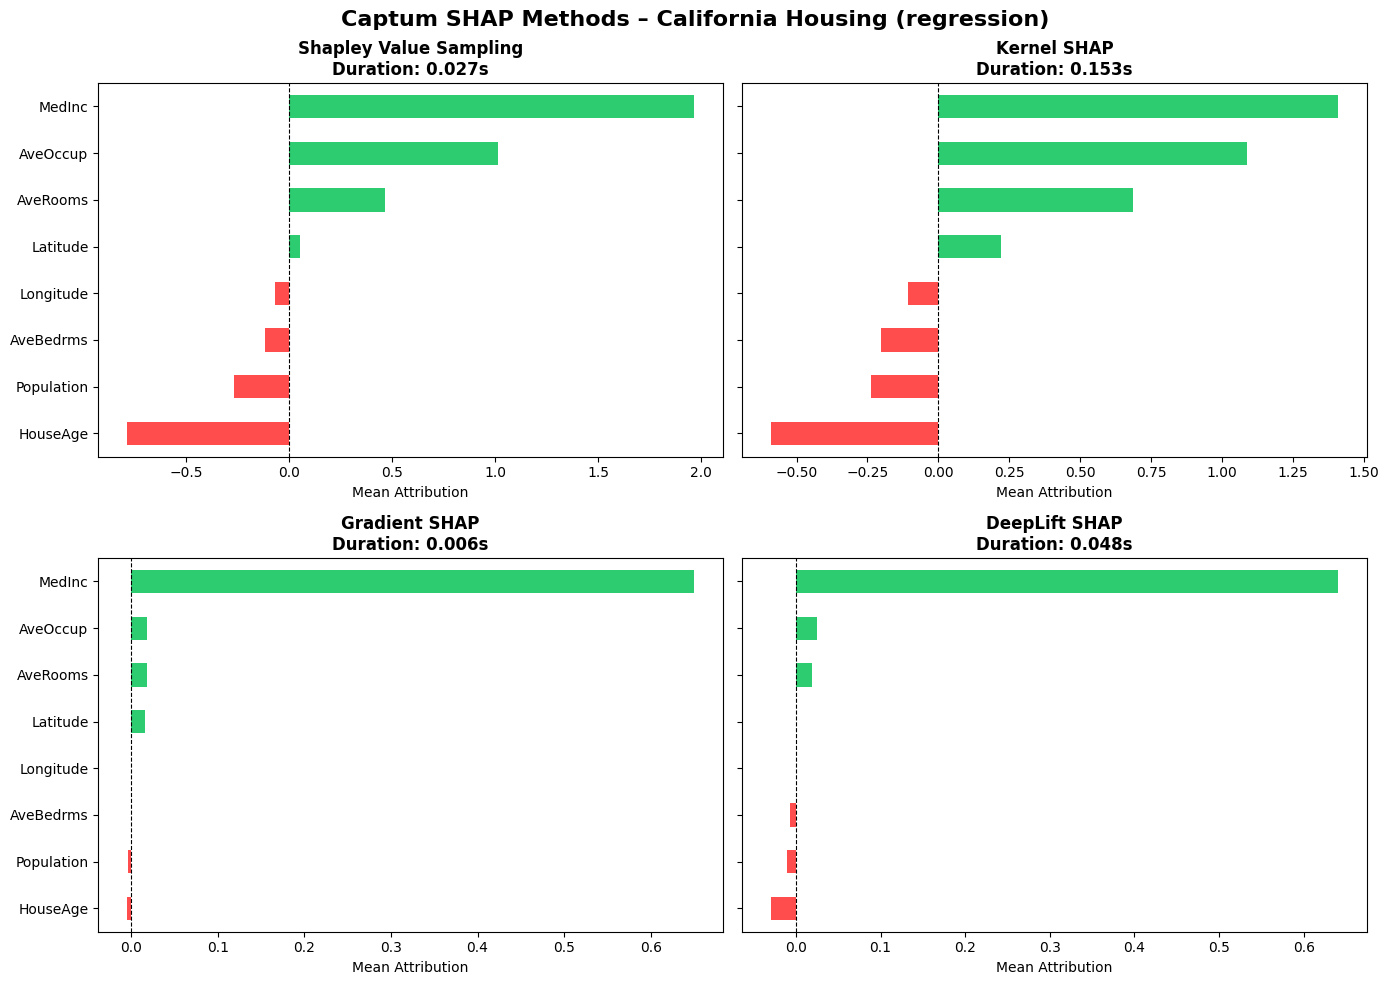


=== Ames Housing (regression) ===
  Shapley Value Sampling...
  Kernel SHAP...
  Gradient SHAP...
  DeepLift SHAP...
  Runtimes: Shapley Value Sampling: 0.241s | Kernel SHAP: 0.147s | Gradient SHAP: 0.001s | DeepLift SHAP: 0.034s


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/captum/attr/_core/lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/captum/attr/_core/deep_lift.py:811: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


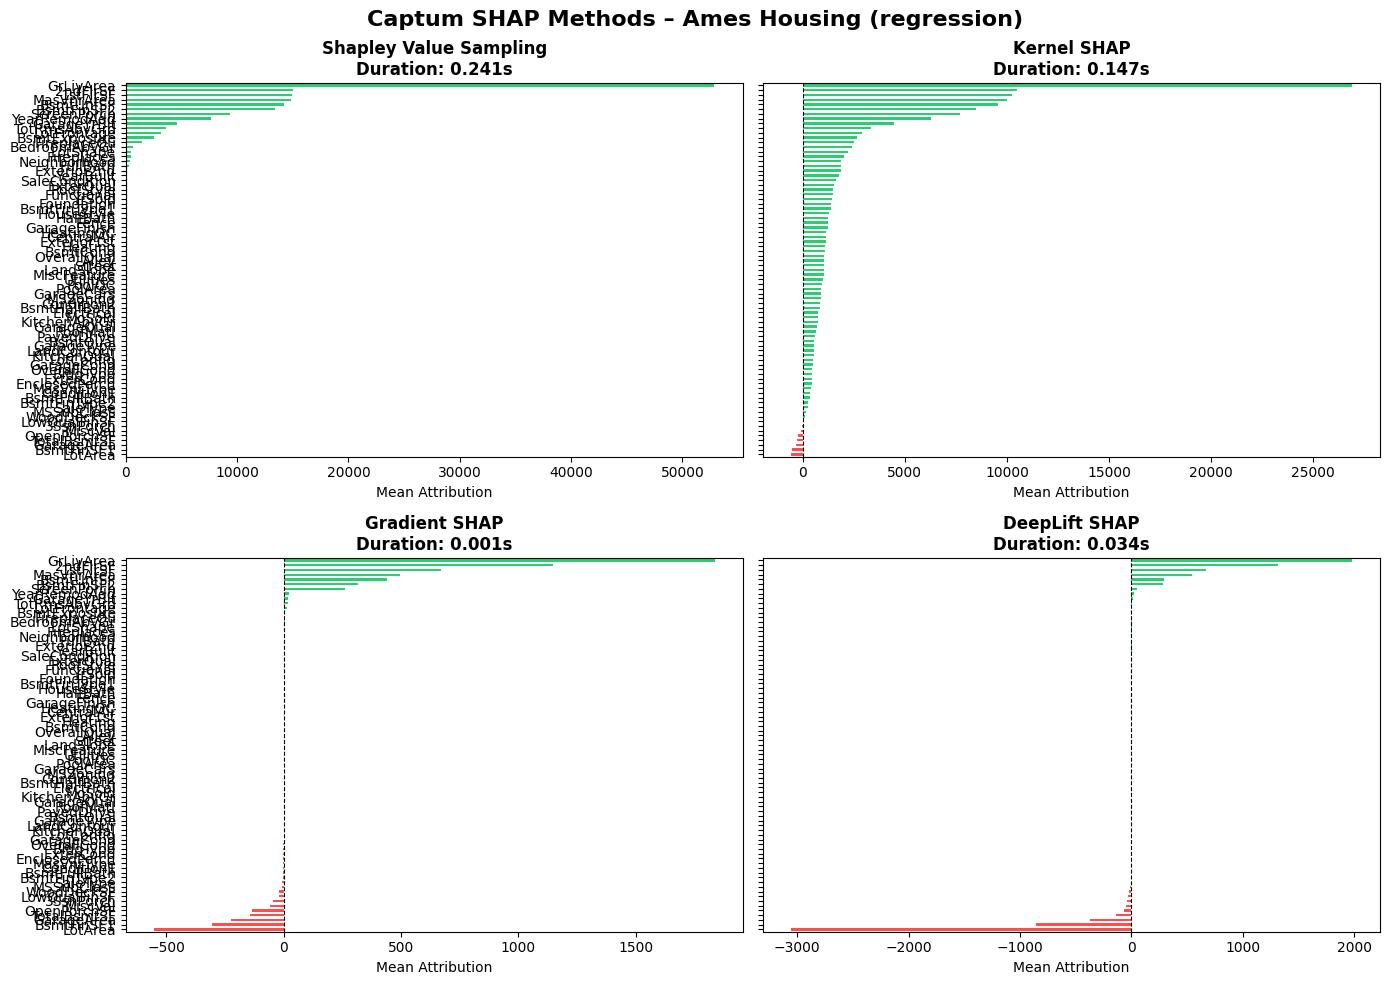


=== Forest Covertype (classification) ===
  Shapley Value Sampling...
  Kernel SHAP...


/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/captum/attr/_core/lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
/Users/felix/Documents/workspace/Master-Informatik/SS26/AIML-PR/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/captum/attr/_core/deep_lift.py:811: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


  Gradient SHAP...
  DeepLift SHAP...
  Runtimes: Shapley Value Sampling: 0.124s | Kernel SHAP: 0.148s | Gradient SHAP: 0.002s | DeepLift SHAP: 0.034s


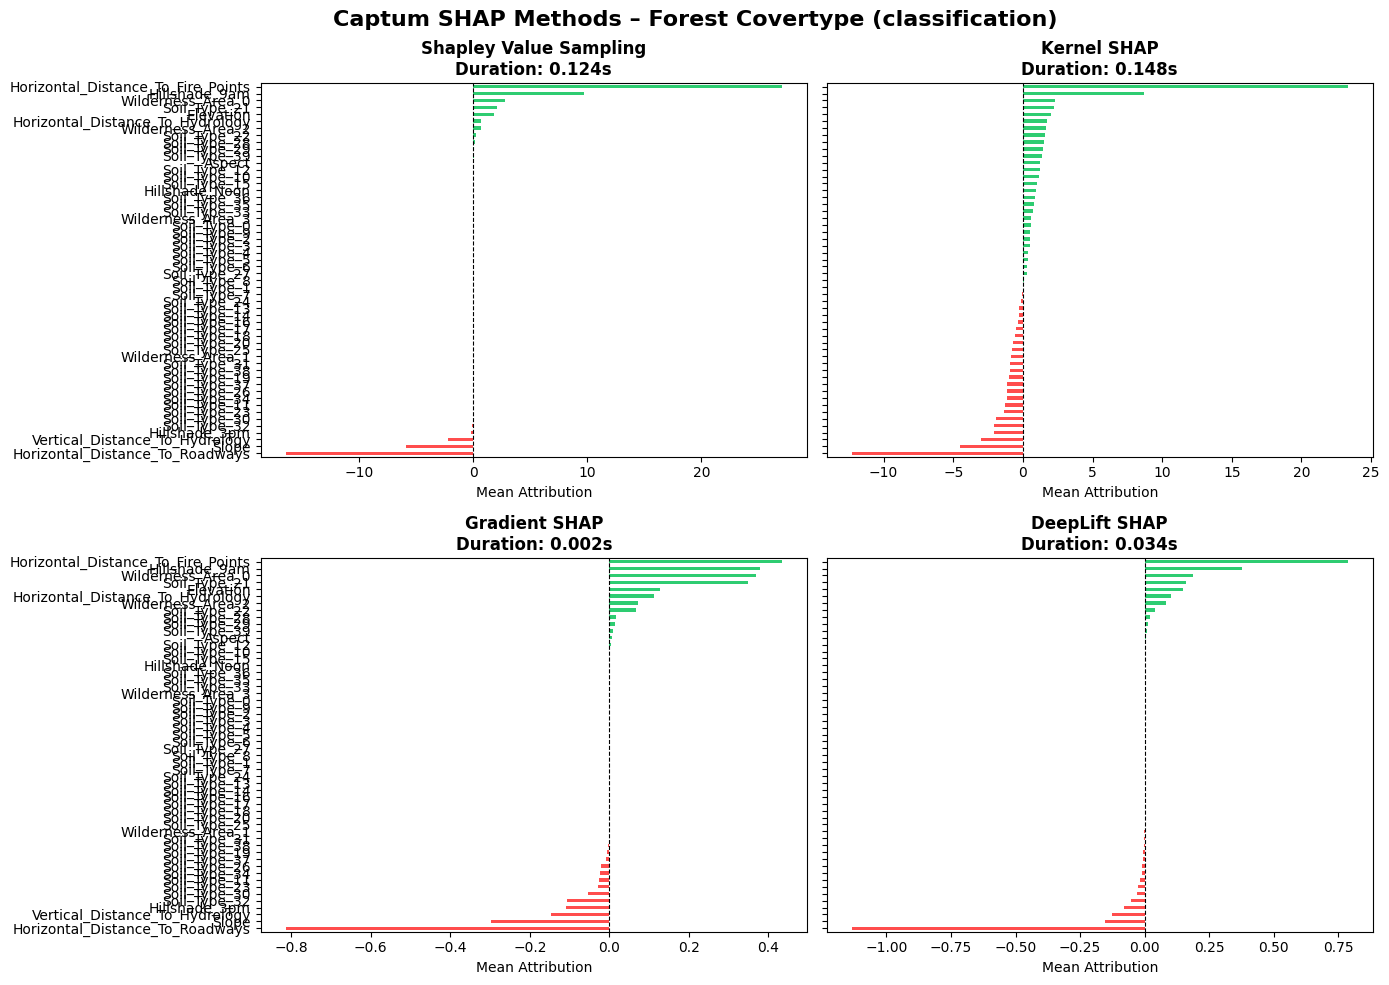

In [4]:
for config, model in zip(all_combi_configs, all_trained_models):
    data = config.dataset.load_dataset()
    X = data["X"]
    feature_names = data["feature_names"]

    model.eval()

    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    baseline_dist = X_tensor[:100]
    eval_inputs   = X_tensor[100:120]
    baseline_zero = torch.zeros(1, X_tensor.shape[1])
    # target=0 selects the single regression output or class 0 for classification
    target = 0

    results  = {}
    durations = {}

    print(f"\n=== {data['name']} ({data['task']}) ===")

    print("  Shapley Value Sampling...")
    start = time.time()
    attr = ShapleyValueSampling(model).attribute(eval_inputs, baselines=baseline_zero, target=target, n_samples=25)
    durations["Shapley Value Sampling"] = time.time() - start
    results["Shapley Value Sampling"] = attr.detach().numpy().mean(axis=0)

    print("  Kernel SHAP...")
    start = time.time()
    attr = KernelShap(model).attribute(eval_inputs, baselines=baseline_zero, target=target, n_samples=50)
    durations["Kernel SHAP"] = time.time() - start
    results["Kernel SHAP"] = attr.detach().numpy().mean(axis=0)

    print("  Gradient SHAP...")
    start = time.time()
    attr = GradientShap(model).attribute(eval_inputs, baselines=baseline_dist, target=target)
    durations["Gradient SHAP"] = time.time() - start
    results["Gradient SHAP"] = attr.detach().numpy().mean(axis=0)

    print("  DeepLift SHAP...")
    start = time.time()
    attr = DeepLiftShap(model).attribute(eval_inputs, baselines=baseline_dist, target=target)
    durations["DeepLift SHAP"] = time.time() - start
    results["DeepLift SHAP"] = attr.detach().numpy().mean(axis=0)

    print("  Runtimes: " + " | ".join(f"{m}: {d:.3f}s" for m, d in durations.items()))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    for ax, (method_name, scores) in zip(axes.flatten(), results.items()):
        df_plot = pd.Series(scores, index=feature_names).sort_values()
        colors = ["#ff4d4d" if v < 0 else "#2ecc71" for v in df_plot.values]
        df_plot.plot(kind="barh", color=colors, ax=ax)
        ax.set_title(f"{method_name}\nDuration: {durations[method_name]:.3f}s", fontsize=12, fontweight="bold")
        ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
        ax.set_xlabel("Mean Attribution")

    plt.suptitle(f"Captum SHAP Methods – {data['name']} ({data['task']})", fontsize=16, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()